# STAR Financing Model with Accelerated Paydown

This notebook models STAR Bond financing with **accelerated principal paydown** using excess revenues.

**Key Feature**: When available revenue exceeds required debt service, a configurable percentage of the excess can be applied to early principal reduction, saving interest costs and potentially retiring bonds early.

**Revenue Streams**:
- **Sales + Use Tax Increment** (primary - state taxes)
- **Liquor Enforcement Tax (LET)**
- **Liquor Drink Tax / Excise**
- **Sports Wagering (APSK)**
- **Local Tax Add-Ins** (optional - Olathe, Wyandotte UG)

Adjust the parameters in the cells below to explore different scenarios.

In [21]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

---
## 1. Parameters

### Adjust these values to explore different scenarios

In [22]:
# =============================================================================
# BOND PARAMETERS
# =============================================================================

PRINCIPAL = 2_400_000_000      # Initial bond principal ($)
INTEREST_RATE = 0.05           # Annual interest rate (0.05 = 5%)
TERM_YEARS = 30                # Total bond term
COVERAGE_RATIO = 1.30          # Required coverage ratio (1.30 = 1.30x)
MAX_CAP_YEARS = 20             # Maximum capitalization period

# =============================================================================
# ACCELERATED PAYDOWN PARAMETER
# =============================================================================
# Percentage of EXCESS revenue (above debt service) to apply to early principal paydown
# 0.0 = No accelerated paydown (standard amortization)
# 0.5 = 50% of excess goes to extra principal
# 1.0 = 100% of excess goes to extra principal (maximum acceleration)

EXCESS_PAYDOWN_PCT = 1.00      # % of excess revenue applied to principal

In [23]:
# =============================================================================
# SALES + USE TAX PARAMETERS
# =============================================================================

SALES_USE_TAX_BASE = 668_000_000   # Frozen base year revenue ($)
SALES_USE_TAX_GROWTH = 0.025       # Annual growth rate (0.025 = 2.5%)

In [24]:
# =============================================================================
# LIQUOR ENFORCEMENT TAX (LET) PARAMETERS
# 8% tax on retail liquor sales
# =============================================================================

LET_BASE = 17_400_000              # Base year LET revenue ($)
LET_GROWTH = 0.02                  # Annual growth rate (0.02 = 2%)

In [25]:
# =============================================================================
# LIQUOR DRINK TAX / EXCISE PARAMETERS
# 10% state portion on drinks
# =============================================================================

LIQUOR_EXCISE_BASE = 8_200_000     # Base year excise revenue ($)
LIQUOR_EXCISE_GROWTH = 0.02        # Annual growth rate (0.02 = 2%)

In [26]:
# =============================================================================
# SPORTS WAGERING (APSK) PARAMETERS
# State's 10% privilege fee on sports betting
# =============================================================================

APSK_STATE_REVENUE = 8_700_000     # Total state sports wagering revenue ($)
APSK_PLEDGE_PCT = 0.75             # Percentage pledged to bonds (0.75 = 75%)
APSK_GROWTH = 0.03                 # Annual growth rate (0.03 = 3%)

### Local Tax Add-Ins (Optional)

These parameters represent **local** sales and use taxes from jurisdictions that could pledge their increment to support STAR bond coverage. These are in addition to the state sales/use tax increment.

**Note**: These are OPTIONAL add-ins. Set INCLUDE_LOCAL_ADD_INS = False to exclude.

In [27]:
# =============================================================================
# LOCAL TAX ADD-IN: OLATHE (Johnson County)
# =============================================================================
# Olathe is a major city in Johnson County, Kansas
# These represent local sales + use tax collections (not state)

INCLUDE_LOCAL_ADD_INS = True       # Set to False to exclude local add-ins

# Olathe Local Taxes (2024 data)
OLATHE_SALES_TAX_BASE = 49_703_253      # Local sales tax ($)
OLATHE_USE_TAX_BASE = 16_186_226        # Local use tax ($)
OLATHE_COMBINED_BASE = OLATHE_SALES_TAX_BASE + OLATHE_USE_TAX_BASE  # $65.89M
OLATHE_GROWTH = 0.035                   # Growth rate (CAGR 2021-24: ~4.1% sales, ~14% use)

In [28]:
# =============================================================================
# LOCAL TAX ADD-IN: WYANDOTTE COUNTY / KANSAS CITY, KS UNIFIED GOVERNMENT
# =============================================================================
# The Unified Government (UG) consists of:
# - Wyandotte County (county portion)
# - Kansas City, KS (city portion)
# Combined, these represent the full UG local tax base

# Wyandotte County portion (2024 data)
WYANDOTTE_CO_SALES_TAX = 32_676_896     # County local sales tax ($)
WYANDOTTE_CO_USE_TAX = 10_729_258       # County local use tax ($)

# Kansas City, KS portion (2024 data)  
KCK_SALES_TAX = 48_143_866              # City local sales tax ($)
KCK_USE_TAX = 15_518_457                # City local use tax ($)

# Combined UG
UG_SALES_TAX_BASE = WYANDOTTE_CO_SALES_TAX + KCK_SALES_TAX   # $80.82M
UG_USE_TAX_BASE = WYANDOTTE_CO_USE_TAX + KCK_USE_TAX         # $26.25M
UG_COMBINED_BASE = UG_SALES_TAX_BASE + UG_USE_TAX_BASE       # $107.07M
UG_GROWTH = 0.035                       # Growth rate (CAGR 2021-24: ~3.6% sales, ~14.6% use)

# Grand total of local add-ins
TOTAL_LOCAL_ADD_IN_BASE = OLATHE_COMBINED_BASE + UG_COMBINED_BASE  # $172.96M

print("LOCAL TAX ADD-IN SUMMARY")
print("=" * 50)
print(f"Olathe:              ${OLATHE_COMBINED_BASE/1e6:,.2f}M")
print(f"Wyandotte UG:        ${UG_COMBINED_BASE/1e6:,.2f}M")
print(f"TOTAL LOCAL ADD-IN:  ${TOTAL_LOCAL_ADD_IN_BASE/1e6:,.2f}M")
print(f"\nAs % of State Base:  {TOTAL_LOCAL_ADD_IN_BASE/SALES_USE_TAX_BASE*100:.1f}%")

LOCAL TAX ADD-IN SUMMARY
Olathe:              $65.89M
Wyandotte UG:        $107.07M
TOTAL LOCAL ADD-IN:  $172.96M

As % of State Base:  25.9%


---
## 2. Model Functions

In [29]:
# =============================================================================
# DATA CLASSES
# =============================================================================

@dataclass
class BondParams:
    """Bond structure parameters"""
    principal: float
    interest_rate: float
    term_years: int
    coverage_ratio: float
    max_cap_years: int = 20

@dataclass
class RevenueStream:
    """A single revenue stream with base and growth"""
    name: str
    base: float
    growth_rate: float
    is_increment: bool = False  # True for STAR increment (base is frozen)
    pledge_pct: float = 1.0     # Percentage pledged (for APSK)

In [30]:
# =============================================================================
# REVENUE CALCULATION FUNCTIONS
# =============================================================================

def calculate_revenue_stream(stream: RevenueStream, years: int) -> np.ndarray:
    """
    Calculate revenue for a stream over time.
    
    For STAR increment streams (is_increment=True):
        - Base is frozen, only growth above base is captured
        - Year N revenue = Base × (1+g)^N - Base
    
    For regular streams:
        - Full revenue is captured with growth
        - Year N revenue = Base × pledge_pct × (1+g)^N
    """
    t = np.arange(1, years + 1)
    
    if stream.is_increment:
        # STAR increment: only capture growth above frozen base
        total = stream.base * (1 + stream.growth_rate) ** t
        revenue = total - stream.base
    else:
        # Regular stream: capture full amount (with pledge percentage)
        revenue = stream.base * stream.pledge_pct * (1 + stream.growth_rate) ** t
    
    return revenue


def calculate_all_revenues(streams: List[RevenueStream], years: int) -> pd.DataFrame:
    """
    Calculate all revenue streams and return a DataFrame.
    """
    df = pd.DataFrame({'year': np.arange(1, years + 1)})
    
    for stream in streams:
        col_name = stream.name.lower().replace(' ', '_')
        df[col_name] = calculate_revenue_stream(stream, years)
    
    # Calculate total
    revenue_cols = [c for c in df.columns if c != 'year']
    df['total_available'] = df[revenue_cols].sum(axis=1)
    df['cumulative'] = df['total_available'].cumsum()
    
    return df

In [31]:
# =============================================================================
# DEBT SERVICE CALCULATION
# =============================================================================

def calculate_level_payment(principal: float, rate: float, periods: int) -> float:
    """
    Calculate level annual debt service (P&I) for amortizing loan.
    
    PMT = P × [r(1+r)^n] / [(1+r)^n - 1]
    """
    if rate == 0:
        return principal / periods
    return principal * (rate * (1 + rate) ** periods) / ((1 + rate) ** periods - 1)

In [32]:
# =============================================================================
# STAR FINANCING SIMULATION WITH ACCELERATED PAYDOWN
# =============================================================================

def simulate_star_financing(
    bond: BondParams,
    streams: List[RevenueStream],
    excess_paydown_pct: float = 0.0,
    max_iterations: int = 50,
    tolerance: float = 1000
) -> Tuple[pd.DataFrame, dict]:
    """
    Simulate STAR financing with capitalized interest and optional accelerated paydown.
    
    During capitalization period (when available revenue < required coverage):
    - Available revenue pays partial interest
    - Shortfall is capitalized (added to principal)
    
    After capitalization:
    - Level debt service payments begin
    - Excess revenue (above debt service) can be applied to extra principal paydown
    - excess_paydown_pct controls what fraction of excess goes to principal (0.0 to 1.0)
    
    Args:
        bond: Bond parameters
        streams: List of revenue streams
        excess_paydown_pct: Fraction of excess revenue to apply to principal (0.0-1.0)
        max_iterations: Max iterations for convergence
        tolerance: Convergence tolerance in dollars
    
    Returns:
        DataFrame with year-by-year results, summary dict
    """
    
    # Calculate all revenue streams
    revenue_df = calculate_all_revenues(streams, bond.term_years)
    available = revenue_df['total_available'].values
    
    # Iteratively solve for debt service (converges when cap period stabilizes)
    debt_service = calculate_level_payment(bond.principal, bond.interest_rate, bond.term_years)
    prev_final_principal = 0
    
    for iteration in range(max_iterations):
        principal = bond.principal
        cap_years = 0
        
        for year in range(bond.term_years):
            interest_due = principal * bond.interest_rate
            avail = available[year]
            required = debt_service * bond.coverage_ratio
            
            if year < bond.max_cap_years and avail < required:
                # Capitalize shortfall
                paid = min(avail, interest_due)
                shortfall = interest_due - paid
                principal += shortfall
                cap_years = year + 1
            else:
                break
        
        if abs(principal - prev_final_principal) < tolerance:
            break
        
        prev_final_principal = principal
        remaining = bond.term_years - cap_years
        if remaining <= 0:
            remaining = 1
        debt_service = calculate_level_payment(principal, bond.interest_rate, remaining)
    
    # Final simulation with converged parameters AND accelerated paydown
    results = []
    principal = bond.principal
    capitalized_interest = 0
    total_extra_principal = 0
    payoff_year = None
    
    for year in range(bond.term_years):
        avail = available[year]
        
        # Check if bonds already paid off
        if principal <= 0:
            results.append({
                'year': year + 1,
                'available_revenue': avail,
                'interest_due': 0,
                'interest_paid': 0,
                'interest_capitalized': 0,
                'principal_paid': 0,
                'extra_principal': 0,
                'debt_service': 0,
                'ending_principal': 0,
                'coverage_ratio': float('inf'),
                'in_cap_period': False,
                'excess_revenue': avail,
                'bonds_retired': True
            })
            continue
        
        interest_due = principal * bond.interest_rate
        
        if year < cap_years:
            # Capitalization period
            interest_paid = min(avail, interest_due)
            interest_cap = interest_due - interest_paid
            principal_paid = 0
            extra_principal = 0
            principal += interest_cap
            capitalized_interest += interest_cap
            actual_ds = interest_paid
            excess = 0
        else:
            # Amortization period
            interest_paid = principal * bond.interest_rate
            scheduled_principal = min(debt_service - interest_paid, principal)
            principal_paid = scheduled_principal
            interest_cap = 0
            actual_ds = interest_paid + principal_paid
            
            # Calculate excess and apply accelerated paydown
            excess = max(0, avail - debt_service)
            extra_principal = min(excess * excess_paydown_pct, principal - principal_paid)
            extra_principal = max(0, extra_principal)  # Ensure non-negative
            
            total_extra_principal += extra_principal
            principal -= (principal_paid + extra_principal)
            
            # Check for early payoff
            if principal <= 0 and payoff_year is None:
                payoff_year = year + 1
                principal = 0
        
        coverage = avail / debt_service if debt_service > 0 else float('inf')
        
        results.append({
            'year': year + 1,
            'available_revenue': avail,
            'interest_due': interest_due if year < cap_years else interest_paid,
            'interest_paid': interest_paid,
            'interest_capitalized': interest_cap,
            'principal_paid': principal_paid,
            'extra_principal': extra_principal,
            'debt_service': actual_ds,
            'ending_principal': max(0, principal),
            'coverage_ratio': coverage,
            'in_cap_period': year < cap_years,
            'excess_revenue': excess if year >= cap_years else 0,
            'bonds_retired': principal <= 0
        })
    
    df = pd.DataFrame(results)
    
    # Merge with revenue breakdown
    df = df.merge(revenue_df, on='year')
    
    # Summary statistics
    total_interest_paid = df['interest_paid'].sum()
    total_interest = capitalized_interest + total_interest_paid
    total_principal_paid = df['principal_paid'].sum() + df['extra_principal'].sum()
    
    # Calculate interest savings vs no acceleration
    # Re-run without acceleration to compare
    if excess_paydown_pct > 0:
        _, baseline = simulate_star_financing(bond, streams, excess_paydown_pct=0.0)
        interest_savings = baseline['total_interest'] - total_interest
        years_saved = baseline['term_years'] - (payoff_year if payoff_year else bond.term_years)
    else:
        interest_savings = 0
        years_saved = 0
    
    summary = {
        'initial_principal': bond.principal,
        'interest_rate': bond.interest_rate,
        'term_years': bond.term_years,
        'coverage_ratio': bond.coverage_ratio,
        'excess_paydown_pct': excess_paydown_pct,
        'capitalization_years': cap_years,
        'amortization_years': bond.term_years - cap_years,
        'principal_after_cap': bond.principal + capitalized_interest,
        'annual_debt_service': debt_service,
        'total_interest_capitalized': capitalized_interest,
        'total_interest_paid': total_interest_paid,
        'total_interest': total_interest,
        'interest_pct_of_principal': total_interest / bond.principal * 100,
        'total_revenue_30yr': df['total_available'].sum(),
        'total_extra_principal': total_extra_principal,
        'payoff_year': payoff_year,
        'interest_savings': interest_savings,
        'years_saved': years_saved,
        'viable': cap_years < bond.max_cap_years
    }
    
    return df, summary

---
## 3. Run the Model

In [33]:
# =============================================================================
# CREATE REVENUE STREAMS FROM PARAMETERS
# =============================================================================

revenue_streams = [
    RevenueStream(
        name='Sales_Use_Increment',
        base=SALES_USE_TAX_BASE,
        growth_rate=SALES_USE_TAX_GROWTH,
        is_increment=True  # STAR increment - only growth above base
    ),
    RevenueStream(
        name='LET',
        base=LET_BASE,
        growth_rate=LET_GROWTH
    ),
    RevenueStream(
        name='Liquor_Excise',
        base=LIQUOR_EXCISE_BASE,
        growth_rate=LIQUOR_EXCISE_GROWTH
    ),
    RevenueStream(
        name='APSK',
        base=APSK_STATE_REVENUE,
        growth_rate=APSK_GROWTH,
        pledge_pct=APSK_PLEDGE_PCT
    )
]

# Add local tax add-ins if enabled
if INCLUDE_LOCAL_ADD_INS:
    # Olathe Local Increment (STAR - only growth above frozen base)
    revenue_streams.append(
        RevenueStream(
            name='Olathe_Local',
            base=OLATHE_COMBINED_BASE,
            growth_rate=OLATHE_GROWTH,
            is_increment=True  # STAR increment
        )
    )
    
    # Wyandotte UG Local Increment (STAR - only growth above frozen base)
    revenue_streams.append(
        RevenueStream(
            name='Wyandotte_UG_Local',
            base=UG_COMBINED_BASE,
            growth_rate=UG_GROWTH,
            is_increment=True  # STAR increment
        )
    )

# Create bond parameters
bond_params = BondParams(
    principal=PRINCIPAL,
    interest_rate=INTEREST_RATE,
    term_years=TERM_YEARS,
    coverage_ratio=COVERAGE_RATIO,
    max_cap_years=MAX_CAP_YEARS
)

print("Revenue Streams:")
print("=" * 70)
for stream in revenue_streams:
    base_amt = stream.base * stream.pledge_pct
    inc_flag = " (STAR increment)" if stream.is_increment else ""
    print(f"  {stream.name:25} ${base_amt:>15,.0f}  ({stream.growth_rate:.1%} growth){inc_flag}")
print("=" * 70)
if INCLUDE_LOCAL_ADD_INS:
    print(f"\nLocal Add-Ins: INCLUDED (Olathe + Wyandotte UG = ${TOTAL_LOCAL_ADD_IN_BASE/1e6:.1f}M base)")
else:
    print("\nLocal Add-Ins: NOT INCLUDED")

Revenue Streams:
  Sales_Use_Increment       $    668,000,000  (2.5% growth) (STAR increment)
  LET                       $     17,400,000  (2.0% growth)
  Liquor_Excise             $      8,200,000  (2.0% growth)
  APSK                      $      6,525,000  (3.0% growth)
  Olathe_Local              $     65,889,479  (3.5% growth) (STAR increment)
  Wyandotte_UG_Local        $    107,068,477  (3.5% growth) (STAR increment)

Local Add-Ins: INCLUDED (Olathe + Wyandotte UG = $173.0M base)


In [34]:
# =============================================================================
# RUN SIMULATION WITH ACCELERATED PAYDOWN
# =============================================================================

df, summary = simulate_star_financing(bond_params, revenue_streams, excess_paydown_pct=EXCESS_PAYDOWN_PCT)

print("\n" + "=" * 70)
print("STAR FINANCING MODEL RESULTS (WITH ACCELERATED PAYDOWN)")
print("=" * 70)

print(f"""
BOND PARAMETERS
---------------
Principal:           ${summary['initial_principal']:,.0f}
Interest Rate:       {summary['interest_rate']:.2%}
Term:                {summary['term_years']} years
Coverage Ratio:      {summary['coverage_ratio']:.2f}x
Excess Paydown %:    {summary['excess_paydown_pct']:.0%}

RESULTS
-------
Capitalization Years:    {summary['capitalization_years']}
Amortization Years:      {summary['amortization_years']}
Principal After Cap:     ${summary['principal_after_cap']:,.0f}
Annual Debt Service:     ${summary['annual_debt_service']:,.0f}

INTEREST COSTS
--------------
Interest Capitalized:    ${summary['total_interest_capitalized']:,.0f}
Interest Paid:           ${summary['total_interest_paid']:,.0f}
TOTAL INTEREST:          ${summary['total_interest']:,.0f}
Interest as % of P:      {summary['interest_pct_of_principal']:.1f}%

ACCELERATED PAYDOWN
-------------------
Extra Principal Paid:    ${summary['total_extra_principal']:,.0f}
""")

if summary['payoff_year']:
    print(f"EARLY PAYOFF IN YEAR:    {summary['payoff_year']}")
else:
    print(f"Payoff Year:             {summary['term_years']} (full term)")

if summary['interest_savings'] > 0:
    print(f"""
SAVINGS vs. NO ACCELERATION
---------------------------
Interest Saved:          ${summary['interest_savings']:,.0f}
Years Saved:             {summary['years_saved']:.0f}
""")

print(f"""
30-YEAR REVENUE
---------------
Total Available:         ${summary['total_revenue_30yr']:,.0f}
""")

if summary['viable']:
    print(f"✓ VIABLE: Coverage met in Year {summary['capitalization_years'] + 1}")
else:
    print(f"⚠️  NOT VIABLE: Capitalization exceeds {MAX_CAP_YEARS} years")


STAR FINANCING MODEL RESULTS (WITH ACCELERATED PAYDOWN)

BOND PARAMETERS
---------------
Principal:           $2,400,000,000
Interest Rate:       5.00%
Term:                30 years
Coverage Ratio:      1.30x
Excess Paydown %:    100%

RESULTS
-------
Capitalization Years:    7
Amortization Years:      23
Principal After Cap:     $2,528,874,906
Annual Debt Service:     $183,269,842

INTEREST COSTS
--------------
Interest Capitalized:    $128,874,906
Interest Paid:           $1,519,347,931
TOTAL INTEREST:          $1,648,222,836
Interest as % of P:      68.7%

ACCELERATED PAYDOWN
-------------------
Extra Principal Paid:    $1,621,873,082

EARLY PAYOFF IN YEAR:    17

SAVINGS vs. NO ACCELERATION
---------------------------
Interest Saved:          $1,087,044,073
Years Saved:             13


30-YEAR REVENUE
---------------
Total Available:         $15,451,550,426

✓ VIABLE: Coverage met in Year 8


---
## 4. Amortization Schedule

In [35]:
# =============================================================================
# DISPLAY AMORTIZATION SCHEDULE WITH ACCELERATED PAYDOWN
# =============================================================================

# Format for display
schedule = df[['year', 'available_revenue', 'debt_service', 'interest_paid', 
               'interest_capitalized', 'principal_paid', 'extra_principal',
               'ending_principal', 'coverage_ratio', 'in_cap_period']].copy()

# Find last year with outstanding principal
last_active_year = schedule[schedule['ending_principal'] > 0]['year'].max()
if pd.isna(last_active_year):
    last_active_year = 1

# Show first 15 years and last 5 active years
print("\nAMORTIZATION SCHEDULE WITH ACCELERATED PAYDOWN (First 15 years)")
print("=" * 140)
print(f"{'Year':>5} {'Available':>15} {'Debt Svc':>12} {'Int Paid':>12} {'Int Cap':>10} {'Prin Paid':>12} {'Extra Prin':>12} {'End Prin':>14} {'Coverage':>10} {'Period':>8}")
print("-" * 140)

for _, row in schedule.head(15).iterrows():
    period = 'CAP' if row['in_cap_period'] else 'AMORT'
    if row['ending_principal'] == 0 and row['year'] > 1:
        period = 'PAID'
    print(f"{row['year']:>5} ${row['available_revenue']/1e6:>13.1f}M ${row['debt_service']/1e6:>10.1f}M "
          f"${row['interest_paid']/1e6:>10.1f}M ${row['interest_capitalized']/1e6:>8.1f}M "
          f"${row['principal_paid']/1e6:>10.1f}M ${row['extra_principal']/1e6:>10.1f}M "
          f"${row['ending_principal']/1e9:>12.2f}B "
          f"{row['coverage_ratio']:>9.2f}x {period:>8}")

# Show remaining active years if bonds not yet paid off by year 15
if last_active_year > 15:
    print("\n... (middle years omitted) ...\n")
    
    print("AMORTIZATION SCHEDULE (Last 5 active years)")
    print("-" * 140)
    
    # Get years around payoff
    if summary['payoff_year'] and summary['payoff_year'] <= 30:
        end_display = min(summary['payoff_year'] + 2, 30)
        start_display = max(end_display - 5, 16)
    else:
        start_display = 26
        end_display = 30
    
    for _, row in schedule[(schedule['year'] >= start_display) & (schedule['year'] <= end_display)].iterrows():
        period = 'CAP' if row['in_cap_period'] else 'AMORT'
        if row['ending_principal'] == 0:
            period = 'PAID'
        print(f"{row['year']:>5} ${row['available_revenue']/1e6:>13.1f}M ${row['debt_service']/1e6:>10.1f}M "
              f"${row['interest_paid']/1e6:>10.1f}M ${row['interest_capitalized']/1e6:>8.1f}M "
              f"${row['principal_paid']/1e6:>10.1f}M ${row['extra_principal']/1e6:>10.1f}M "
              f"${row['ending_principal']/1e9:>12.2f}B "
              f"{row['coverage_ratio']:>9.2f}x {period:>8}")

# Summary
print("\n" + "=" * 140)
total_extra = schedule['extra_principal'].sum()
print(f"TOTAL EXTRA PRINCIPAL PAID: ${total_extra/1e6:,.1f}M")
if summary['payoff_year']:
    print(f"BONDS FULLY RETIRED IN YEAR {summary['payoff_year']} ({30 - summary['payoff_year']} years early)")


AMORTIZATION SCHEDULE WITH ACCELERATED PAYDOWN (First 15 years)
 Year       Available     Debt Svc     Int Paid    Int Cap    Prin Paid   Extra Prin       End Prin   Coverage   Period
--------------------------------------------------------------------------------------------------------------------------------------------
    1 $         55.6M $      55.6M $      55.6M $    64.4M $       0.0M $       0.0M $        2.46B      0.30x      CAP
    2 $         79.7M $      79.7M $      79.7M $    43.5M $       0.0M $       0.0M $        2.51B      0.43x      CAP
    3 $        104.5M $     104.5M $     104.5M $    20.9M $       0.0M $       0.0M $        2.53B      0.57x      CAP
    4 $        129.9M $     126.4M $     126.4M $     0.0M $       0.0M $       0.0M $        2.53B      0.71x      CAP
    5 $        156.1M $     126.4M $     126.4M $     0.0M $       0.0M $       0.0M $        2.53B      0.85x      CAP
    6 $        182.9M $     126.4M $     126.4M $     0.0M $       0.0M $ 

---
## 5. Visualizations

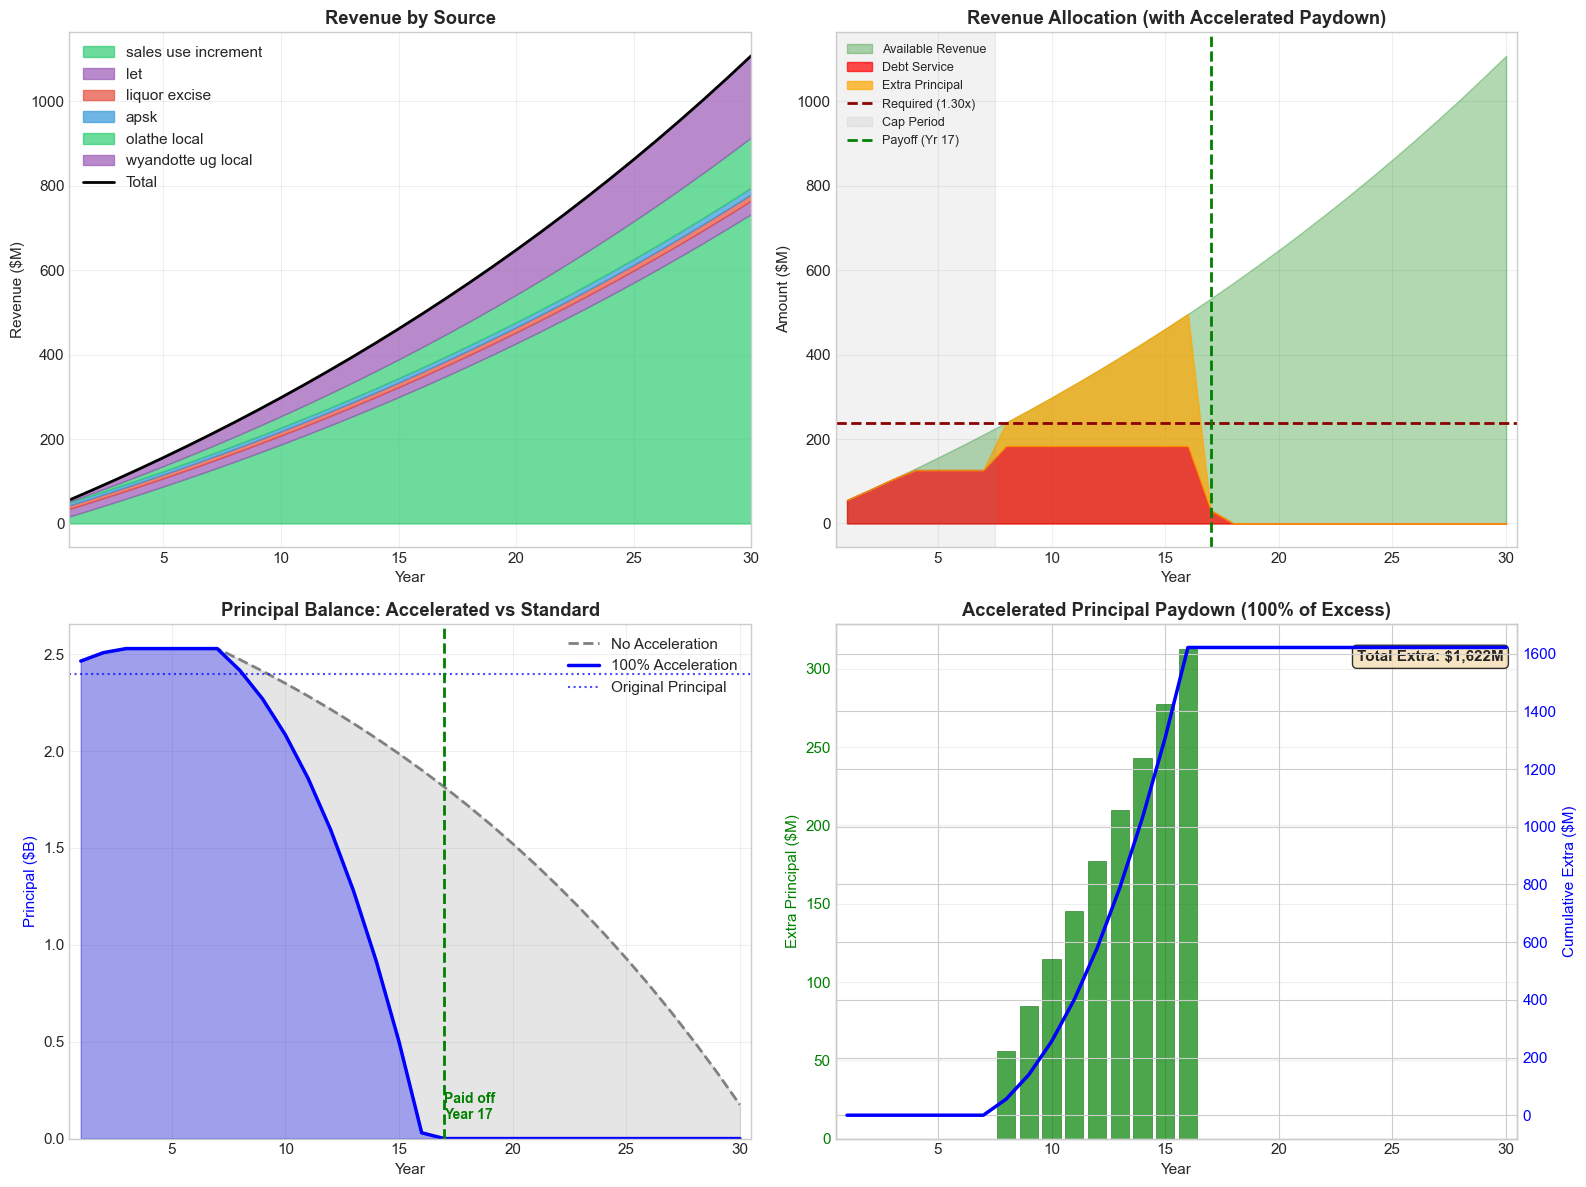


Dashboard saved to: data/star_financing_accelerated_dashboard.png


In [36]:
# =============================================================================
# VISUALIZATION: 4-PANEL DASHBOARD WITH ACCELERATED PAYDOWN
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

years = df['year'].values
cap_years = summary['capitalization_years']
payoff_year = summary['payoff_year']

# -----------------------------------------------------------------------------
# PLOT 1: Revenue Stack by Source
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]

# Get revenue columns
rev_cols = [c for c in df.columns if c not in ['year', 'total_available', 'cumulative', 
            'available_revenue', 'interest_due', 'interest_paid', 'interest_capitalized',
            'principal_paid', 'extra_principal', 'debt_service', 'ending_principal', 
            'coverage_ratio', 'in_cap_period', 'excess_revenue', 'bonds_retired']]

colors = ['#2ecc71', '#9b59b6', '#e74c3c', '#3498db']
bottom = np.zeros(len(years))

for i, col in enumerate(rev_cols):
    values = df[col].values / 1e6
    ax1.fill_between(years, bottom, bottom + values, alpha=0.7, 
                     color=colors[i % len(colors)], label=col.replace('_', ' '))
    bottom += values

ax1.plot(years, df['total_available'].values / 1e6, 'k-', linewidth=2, label='Total')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue ($M)')
ax1.set_title('Revenue by Source', fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_xlim(1, 30)
ax1.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 2: Revenue vs Debt Service + Extra Principal
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]

ax2.fill_between(years, 0, df['total_available'].values / 1e6, alpha=0.3, 
                 color='green', label='Available Revenue')

# Stack: debt service + extra principal
ds = df['debt_service'].values / 1e6
extra = df['extra_principal'].values / 1e6
ax2.fill_between(years, 0, ds, alpha=0.7, color='red', label='Debt Service')
ax2.fill_between(years, ds, ds + extra, alpha=0.7, color='orange', label='Extra Principal')

ax2.axhline(y=summary['annual_debt_service'] * COVERAGE_RATIO / 1e6, 
            color='darkred', linestyle='--', linewidth=2, 
            label=f'Required ({COVERAGE_RATIO:.2f}x)')
ax2.axvspan(0.5, cap_years + 0.5, alpha=0.1, color='gray', label='Cap Period')

if payoff_year:
    ax2.axvline(x=payoff_year, color='green', linestyle='--', linewidth=2, 
                label=f'Payoff (Yr {payoff_year})')

ax2.set_xlabel('Year')
ax2.set_ylabel('Amount ($M)')
ax2.set_title('Revenue Allocation (with Accelerated Paydown)', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xlim(0.5, 30.5)
ax2.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 3: Principal Balance Comparison
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]

# Run baseline (no acceleration) for comparison
_, baseline_summary = simulate_star_financing(bond_params, revenue_streams, excess_paydown_pct=0.0)
baseline_df, _ = simulate_star_financing(bond_params, revenue_streams, excess_paydown_pct=0.0)

# Plot both principal curves
ax3.fill_between(years, 0, baseline_df['ending_principal'].values / 1e9, alpha=0.2, color='gray')
ax3.plot(years, baseline_df['ending_principal'].values / 1e9, 'gray', linewidth=2, 
         linestyle='--', label='No Acceleration')

ax3.fill_between(years, 0, df['ending_principal'].values / 1e9, alpha=0.3, color='blue')
ax3.plot(years, df['ending_principal'].values / 1e9, 'b-', linewidth=2.5, 
         label=f'{EXCESS_PAYDOWN_PCT:.0%} Acceleration')

ax3.axhline(y=PRINCIPAL / 1e9, color='blue', linestyle=':', linewidth=1.5, 
            alpha=0.7, label='Original Principal')

if payoff_year:
    ax3.axvline(x=payoff_year, color='green', linestyle='--', linewidth=2)
    ax3.annotate(f'Paid off\nYear {payoff_year}', xy=(payoff_year, 0.1), 
                 fontsize=10, color='green', fontweight='bold')

ax3.set_xlabel('Year')
ax3.set_ylabel('Principal ($B)', color='blue')
ax3.set_title('Principal Balance: Accelerated vs Standard', fontweight='bold')
ax3.legend(loc='upper right')
ax3.set_xlim(0.5, 30.5)
ax3.set_ylim(0, None)
ax3.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 4: Extra Principal Paid Per Year
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]

# Bar chart of extra principal by year
extra_principal = df['extra_principal'].values / 1e6
bar_colors = ['green' if ep > 0 else 'lightgray' for ep in extra_principal]

ax4.bar(years, extra_principal, color=bar_colors, alpha=0.7, edgecolor='darkgreen', linewidth=0.5)
ax4.axhline(y=0, color='black', linewidth=0.5)

# Add cumulative line on secondary axis
ax4_twin = ax4.twinx()
cumulative_extra = np.cumsum(extra_principal)
ax4_twin.plot(years, cumulative_extra, 'b-', linewidth=2.5, label='Cumulative')
ax4_twin.set_ylabel('Cumulative Extra ($M)', color='blue')
ax4_twin.tick_params(axis='y', labelcolor='blue')

ax4.set_xlabel('Year')
ax4.set_ylabel('Extra Principal ($M)', color='green')
ax4.tick_params(axis='y', labelcolor='green')
ax4.set_title(f'Accelerated Principal Paydown ({EXCESS_PAYDOWN_PCT:.0%} of Excess)', fontweight='bold')
ax4.set_xlim(0.5, 30.5)
ax4.grid(True, alpha=0.3, axis='y')

# Add total annotation
total_extra = extra_principal.sum()
ax4.annotate(f'Total Extra: ${total_extra:,.0f}M', 
             xy=(0.98, 0.95), xycoords='axes fraction',
             fontsize=11, fontweight='bold', ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('data/star_financing_accelerated_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nDashboard saved to: data/star_financing_accelerated_dashboard.png")

---
## 6. Sensitivity Analysis

In [37]:
# =============================================================================
# SENSITIVITY ANALYSIS FUNCTION (WITH ACCELERATED PAYDOWN)
# =============================================================================

def run_sensitivity_analysis(
    base_streams: List[RevenueStream],
    bond: BondParams,
    interest_rates: List[float],
    growth_rates: List[float],
    paydown_pct: float = 0.0
) -> pd.DataFrame:
    """
    Run sensitivity analysis varying interest rate and growth rate.
    Growth rate is applied to the Sales+Use increment stream.
    """
    results = []
    
    for rate in interest_rates:
        for growth in growth_rates:
            # Create modified streams
            mod_streams = []
            for s in base_streams:
                if s.is_increment:  # Sales+Use increment
                    mod_streams.append(RevenueStream(
                        name=s.name, base=s.base, growth_rate=growth,
                        is_increment=True, pledge_pct=s.pledge_pct
                    ))
                else:
                    # Scale other growth rates proportionally
                    scaled_growth = max(0.01, growth - 0.005)
                    mod_streams.append(RevenueStream(
                        name=s.name, base=s.base, growth_rate=scaled_growth,
                        is_increment=False, pledge_pct=s.pledge_pct
                    ))
            
            # Create modified bond
            mod_bond = BondParams(
                principal=bond.principal,
                interest_rate=rate,
                term_years=bond.term_years,
                coverage_ratio=bond.coverage_ratio,
                max_cap_years=bond.max_cap_years
            )
            
            try:
                _, summ = simulate_star_financing(mod_bond, mod_streams, excess_paydown_pct=paydown_pct)
                
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'paydown_pct': paydown_pct,
                    'cap_years': summ['capitalization_years'] if summ['viable'] else np.nan,
                    'debt_service_M': summ['annual_debt_service'] / 1e6 if summ['viable'] else np.nan,
                    'total_interest_B': summ['total_interest'] / 1e9 if summ['viable'] else np.nan,
                    'payoff_year': summ['payoff_year'] if summ['viable'] else np.nan,
                    'extra_principal_M': summ['total_extra_principal'] / 1e6 if summ['viable'] else np.nan,
                    'viable': summ['viable']
                })
            except:
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'paydown_pct': paydown_pct,
                    'cap_years': np.nan,
                    'debt_service_M': np.nan,
                    'total_interest_B': np.nan,
                    'payoff_year': np.nan,
                    'extra_principal_M': np.nan,
                    'viable': False
                })
    
    return pd.DataFrame(results)


def run_paydown_comparison(
    base_streams: List[RevenueStream],
    bond: BondParams,
    paydown_percentages: List[float]
) -> pd.DataFrame:
    """
    Compare different accelerated paydown percentages.
    """
    results = []
    
    for pct in paydown_percentages:
        try:
            _, summ = simulate_star_financing(bond, base_streams, excess_paydown_pct=pct)
            
            results.append({
                'paydown_pct': pct,
                'total_interest_B': summ['total_interest'] / 1e9,
                'extra_principal_M': summ['total_extra_principal'] / 1e6,
                'payoff_year': summ['payoff_year'] if summ['payoff_year'] else summ['term_years'],
                'interest_savings_M': summ['interest_savings'] / 1e6 if summ['interest_savings'] else 0,
                'viable': summ['viable']
            })
        except:
            results.append({
                'paydown_pct': pct,
                'total_interest_B': np.nan,
                'extra_principal_M': np.nan,
                'payoff_year': np.nan,
                'interest_savings_M': np.nan,
                'viable': False
            })
    
    return pd.DataFrame(results)

In [38]:
# =============================================================================
# RUN SENSITIVITY ANALYSIS
# =============================================================================

interest_rates = [0.04, 0.045, 0.05, 0.055, 0.06]
growth_rates = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]

# Run with current paydown percentage
sensitivity_df = run_sensitivity_analysis(
    revenue_streams, bond_params, interest_rates, growth_rates, paydown_pct=EXCESS_PAYDOWN_PCT
)

# Display pivot table
print(f"\nSENSITIVITY ANALYSIS: Capitalization Years (with {EXCESS_PAYDOWN_PCT:.0%} Paydown)")
print("(N/A = Not Viable within max cap period)")
print("=" * 80)
pivot = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
formatted = pivot.copy()
for col in formatted.columns:
    formatted[col] = formatted[col].apply(lambda x: 'N/A' if pd.isna(x) else f'{x:.0f}')
print(formatted.to_string())

# Count non-viable
non_viable = sensitivity_df[sensitivity_df['viable'] == False]
print(f"\n⚠️  Non-viable scenarios: {len(non_viable)} of {len(sensitivity_df)}")

# =============================================================================
# PAYDOWN PERCENTAGE COMPARISON
# =============================================================================

print("\n" + "=" * 80)
print("ACCELERATED PAYDOWN COMPARISON")
print("=" * 80)

paydown_percentages = [0.0, 0.25, 0.50, 0.75, 1.0]
paydown_df = run_paydown_comparison(revenue_streams, bond_params, paydown_percentages)

print(f"\n{'Paydown %':>12} {'Total Interest':>18} {'Extra Principal':>18} {'Payoff Year':>14} {'Interest Saved':>18}")
print("-" * 80)
for _, row in paydown_df.iterrows():
    payoff = f"Year {row['payoff_year']:.0f}" if row['payoff_year'] < 30 else "Year 30 (full)"
    savings = f"${row['interest_savings_M']:,.0f}M" if row['interest_savings_M'] > 0 else "—"
    print(f"{row['paydown_pct']:>11.0%} ${row['total_interest_B']:>15.2f}B ${row['extra_principal_M']:>15.0f}M {payoff:>14} {savings:>18}")

print("\n")
print("Note: Interest savings compared to 0% paydown (standard amortization)")


SENSITIVITY ANALYSIS: Capitalization Years (with 100% Paydown)
(N/A = Not Viable within max cap period)
growth_rate   0.010 0.015 0.020 0.025 0.030 0.035 0.040 0.050
interest_rate                                                
0.040           N/A    14     9     7     6     5     4     3
0.045           N/A    16    10     8     6     5     4     3
0.050           N/A    18    11     8     7     5     5     3
0.055           N/A    19    12     9     7     6     5     4
0.060           N/A   N/A    14    10     8     6     5     4

⚠️  Non-viable scenarios: 6 of 40

ACCELERATED PAYDOWN COMPARISON

   Paydown %     Total Interest    Extra Principal    Payoff Year     Interest Saved
--------------------------------------------------------------------------------
         0% $           2.74B $              0M Year 30 (full)                  —
        25% $           2.10B $           1001M        Year 22              $640M
        50% $           1.87B $           1324M        Year 19 

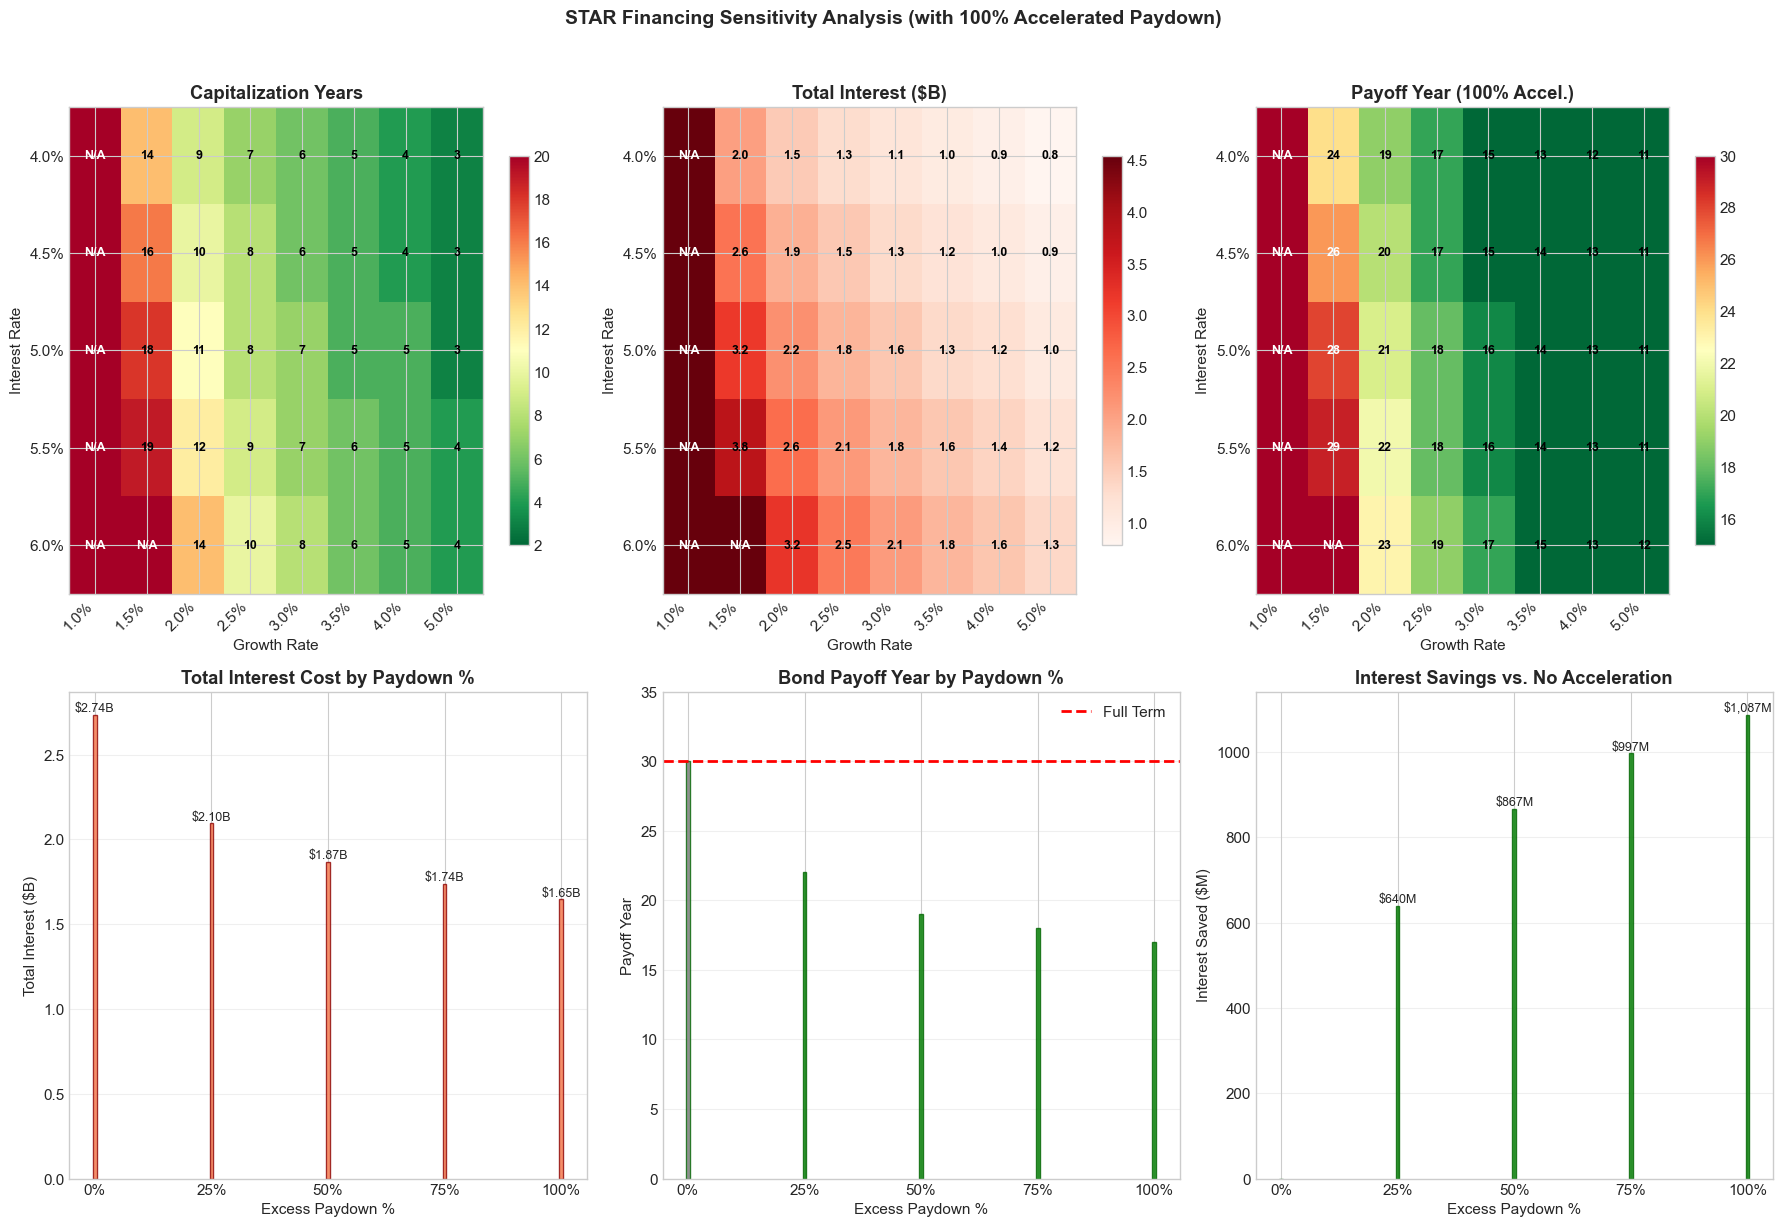


Sensitivity analysis saved to: data/star_accelerated_sensitivity.png


In [39]:
# =============================================================================
# SENSITIVITY HEATMAPS + PAYDOWN COMPARISON CHART
# =============================================================================

fig = plt.figure(figsize=(18, 12))

# Top row: Heatmaps (similar to before)
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)

pivot_cap = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
pivot_int = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='total_interest_B')
pivot_ds = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='debt_service_M')

# Heatmap 1: Cap Years
cap_vals = pivot_cap.values.astype(float)
cap_display = np.where(np.isnan(cap_vals), MAX_CAP_YEARS, cap_vals)
im1 = ax1.imshow(cap_display, cmap='RdYlGn_r', aspect='auto', vmin=2, vmax=MAX_CAP_YEARS)
ax1.set_xticks(range(len(pivot_cap.columns)))
ax1.set_xticklabels([f'{g:.1%}' for g in pivot_cap.columns], rotation=45, ha='right')
ax1.set_yticks(range(len(pivot_cap.index)))
ax1.set_yticklabels([f'{r:.1%}' for r in pivot_cap.index])
ax1.set_xlabel('Growth Rate')
ax1.set_ylabel('Interest Rate')
ax1.set_title('Capitalization Years', fontweight='bold')
for i in range(len(pivot_cap.index)):
    for j in range(len(pivot_cap.columns)):
        val = cap_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'
        color = 'white' if np.isnan(val) else 'black'
        ax1.text(j, i, txt, ha='center', va='center', color=color, fontweight='bold', fontsize=9)
fig.colorbar(im1, ax=ax1, shrink=0.8)

# Heatmap 2: Total Interest
int_vals = pivot_int.values.astype(float)
int_max = np.nanmax(int_vals) * 1.2 if not np.all(np.isnan(int_vals)) else 5
int_display = np.where(np.isnan(int_vals), int_max, int_vals)
im2 = ax2.imshow(int_display, cmap='Reds', aspect='auto')
ax2.set_xticks(range(len(pivot_int.columns)))
ax2.set_xticklabels([f'{g:.1%}' for g in pivot_int.columns], rotation=45, ha='right')
ax2.set_yticks(range(len(pivot_int.index)))
ax2.set_yticklabels([f'{r:.1%}' for r in pivot_int.index])
ax2.set_xlabel('Growth Rate')
ax2.set_ylabel('Interest Rate')
ax2.set_title('Total Interest ($B)', fontweight='bold')
for i in range(len(pivot_int.index)):
    for j in range(len(pivot_int.columns)):
        val = int_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.1f}'
        color = 'white' if np.isnan(val) else 'black'
        ax2.text(j, i, txt, ha='center', va='center', color=color, fontweight='bold', fontsize=9)
fig.colorbar(im2, ax=ax2, shrink=0.8)

# Heatmap 3: Payoff Year
pivot_payoff = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='payoff_year')
payoff_vals = pivot_payoff.values.astype(float)
payoff_display = np.where(np.isnan(payoff_vals), 30, payoff_vals)
im3 = ax3.imshow(payoff_display, cmap='RdYlGn_r', aspect='auto', vmin=15, vmax=30)
ax3.set_xticks(range(len(pivot_payoff.columns)))
ax3.set_xticklabels([f'{g:.1%}' for g in pivot_payoff.columns], rotation=45, ha='right')
ax3.set_yticks(range(len(pivot_payoff.index)))
ax3.set_yticklabels([f'{r:.1%}' for r in pivot_payoff.index])
ax3.set_xlabel('Growth Rate')
ax3.set_ylabel('Interest Rate')
ax3.set_title(f'Payoff Year ({EXCESS_PAYDOWN_PCT:.0%} Accel.)', fontweight='bold')
for i in range(len(pivot_payoff.index)):
    for j in range(len(pivot_payoff.columns)):
        val = payoff_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'
        color = 'white' if np.isnan(val) or val > 25 else 'black'
        ax3.text(j, i, txt, ha='center', va='center', color=color, fontweight='bold', fontsize=9)
fig.colorbar(im3, ax=ax3, shrink=0.8)

# Bottom row: Paydown comparison charts
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

# Chart 4: Total Interest by Paydown %
ax4.bar(paydown_df['paydown_pct'] * 100, paydown_df['total_interest_B'], 
        color='coral', edgecolor='darkred', alpha=0.8)
ax4.set_xlabel('Excess Paydown %')
ax4.set_ylabel('Total Interest ($B)')
ax4.set_title('Total Interest Cost by Paydown %', fontweight='bold')
ax4.set_xticks(paydown_df['paydown_pct'] * 100)
ax4.set_xticklabels([f'{p:.0f}%' for p in paydown_df['paydown_pct'] * 100])
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, row in paydown_df.iterrows():
    ax4.annotate(f'${row["total_interest_B"]:.2f}B', 
                 xy=(row['paydown_pct'] * 100, row['total_interest_B']),
                 ha='center', va='bottom', fontsize=9)

# Chart 5: Payoff Year by Paydown %
colors = ['green' if py < 30 else 'gray' for py in paydown_df['payoff_year']]
ax5.bar(paydown_df['paydown_pct'] * 100, paydown_df['payoff_year'], 
        color=colors, edgecolor='darkgreen', alpha=0.8)
ax5.axhline(y=30, color='red', linestyle='--', linewidth=2, label='Full Term')
ax5.set_xlabel('Excess Paydown %')
ax5.set_ylabel('Payoff Year')
ax5.set_title('Bond Payoff Year by Paydown %', fontweight='bold')
ax5.set_xticks(paydown_df['paydown_pct'] * 100)
ax5.set_xticklabels([f'{p:.0f}%' for p in paydown_df['paydown_pct'] * 100])
ax5.set_ylim(0, 35)
ax5.grid(True, alpha=0.3, axis='y')
ax5.legend(loc='upper right')

# Chart 6: Interest Savings by Paydown %
ax6.bar(paydown_df['paydown_pct'] * 100, paydown_df['interest_savings_M'], 
        color='green', edgecolor='darkgreen', alpha=0.8)
ax6.set_xlabel('Excess Paydown %')
ax6.set_ylabel('Interest Saved ($M)')
ax6.set_title('Interest Savings vs. No Acceleration', fontweight='bold')
ax6.set_xticks(paydown_df['paydown_pct'] * 100)
ax6.set_xticklabels([f'{p:.0f}%' for p in paydown_df['paydown_pct'] * 100])
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, row in paydown_df.iterrows():
    if row['interest_savings_M'] > 0:
        ax6.annotate(f'${row["interest_savings_M"]:,.0f}M', 
                     xy=(row['paydown_pct'] * 100, row['interest_savings_M']),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle(f'STAR Financing Sensitivity Analysis (with {EXCESS_PAYDOWN_PCT:.0%} Accelerated Paydown)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/star_accelerated_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSensitivity analysis saved to: data/star_accelerated_sensitivity.png")

---
## 7. Export Results

In [20]:
# =============================================================================
# EXPORT TO EXCEL
# =============================================================================

# Build parameters list
params_list = [
    ('Principal', f'${PRINCIPAL:,.0f}'),
    ('Interest Rate', f'{INTEREST_RATE:.2%}'),
    ('Term (Years)', TERM_YEARS),
    ('Coverage Ratio', f'{COVERAGE_RATIO:.2f}x'),
    ('Excess Paydown %', f'{EXCESS_PAYDOWN_PCT:.0%}'),
    ('', ''),
    ('--- STATE TAX STREAMS ---', ''),
    ('Sales+Use Base', f'${SALES_USE_TAX_BASE:,.0f}'),
    ('Sales+Use Growth', f'{SALES_USE_TAX_GROWTH:.2%}'),
    ('', ''),
    ('--- ALCOHOL/GAMING ---', ''),
    ('LET Base', f'${LET_BASE:,.0f}'),
    ('LET Growth', f'{LET_GROWTH:.2%}'),
    ('Liquor Excise Base', f'${LIQUOR_EXCISE_BASE:,.0f}'),
    ('Liquor Excise Growth', f'{LIQUOR_EXCISE_GROWTH:.2%}'),
    ('APSK Base', f'${APSK_STATE_REVENUE:,.0f}'),
    ('APSK Pledge %', f'{APSK_PLEDGE_PCT:.0%}'),
    ('APSK Growth', f'{APSK_GROWTH:.2%}'),
]

# Add local add-ins if included
if INCLUDE_LOCAL_ADD_INS:
    params_list.extend([
        ('', ''),
        ('--- LOCAL ADD-INS ---', ''),
        ('Include Local Add-Ins', 'YES'),
        ('Olathe Combined Base', f'${OLATHE_COMBINED_BASE:,.0f}'),
        ('Olathe Growth', f'{OLATHE_GROWTH:.2%}'),
        ('Wyandotte UG Combined Base', f'${UG_COMBINED_BASE:,.0f}'),
        ('Wyandotte UG Growth', f'{UG_GROWTH:.2%}'),
        ('Total Local Add-In Base', f'${TOTAL_LOCAL_ADD_IN_BASE:,.0f}'),
    ])
else:
    params_list.extend([
        ('', ''),
        ('--- LOCAL ADD-INS ---', ''),
        ('Include Local Add-Ins', 'NO'),
    ])

params_df = pd.DataFrame(params_list, columns=['Parameter', 'Value'])

with pd.ExcelWriter('data/star_financing_accelerated_results.xlsx', engine='openpyxl') as writer:
    
    # Parameters sheet
    params_df.to_excel(writer, sheet_name='Parameters', index=False)
    
    # Amortization schedule
    df.to_excel(writer, sheet_name='Amortization Schedule', index=False)
    
    # Sensitivity analysis
    sensitivity_df.to_excel(writer, sheet_name='Sensitivity Analysis', index=False)
    
    # Paydown comparison
    paydown_df.to_excel(writer, sheet_name='Paydown Comparison', index=False)
    
    # Summary
    summary_df = pd.DataFrame([summary])
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print("Results exported to: data/star_financing_accelerated_results.xlsx")
print("\nSheets:")
print("  - Parameters: Input assumptions (including accelerated paydown %)")
print("  - Amortization Schedule: Year-by-year cash flows with extra principal")
print("  - Sensitivity Analysis: Interest rate × growth rate matrix")
print("  - Paydown Comparison: Different paydown % scenarios")
print("  - Summary: Key results including interest savings")

Results exported to: data/star_financing_accelerated_results.xlsx

Sheets:
  - Parameters: Input assumptions (including accelerated paydown %)
  - Amortization Schedule: Year-by-year cash flows with extra principal
  - Sensitivity Analysis: Interest rate × growth rate matrix
  - Paydown Comparison: Different paydown % scenarios
  - Summary: Key results including interest savings
